In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error,r2_score

## Чтение датасета и вывод его размерности

In [2]:
df = pd.read_csv(r"car_web_scraped_dataset.csv")

df['price'] = pd.to_numeric(df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False), errors='coerce')
df['miles'] = pd.to_numeric(df['miles'].str.replace(' miles', '', regex=False).str.replace(',', '', regex=False), errors='coerce')
df = df.dropna(subset=['price', 'miles'])

print(f"Размер таблицы: {df.shape[0]} автомобилей и {df.shape[1]} параметров")

df.head(3)

Размер таблицы: 2840 автомобилей и 6 параметров


,name,year,miles,color,condition,price
0,Kia Forte,2022,41406,"Gray exterior, Black interior","No accidents reported, 1 Owner",15988
1,Chevrolet Silverado 1500,2021,15138,"White exterior, Black interior","1 accident reported, 1 Owner",38008
2,Toyota RAV4,2022,32879,"Silver exterior, Unknown interior","No accidents reported, 1 Owner",24988


## Определение зависимости цены от цвета автомобиля

In [3]:
color_impact = df.groupby("color")["price"].median().sort_values(ascending=False)
print("Топ-10 цветов по медианной цене:\n", color_impact.head(10))

Топ-10 цветов по медианной цене:
 color
Black exterior, White interior      73495.0
Silver exterior, Red interior       69695.0
White exterior, Orange interior     64998.0
Green exterior, Green interior      59998.0
Yellow exterior, Black interior     57444.0
Green exterior, Black interior      41125.0
Red exterior, Brown interior        36998.0
Gray exterior, Brown interior       36996.0
Unknown exterior, Beige interior    35685.0
Blue exterior, Red interior         32555.0
Name: price, dtype: float64


Вывод: цвет слабо влияет на ствоимость автомобиля

## Подготовка признаков

In [4]:
df_model = df.drop(columns=['name'], errors='ignore')

df_model = pd.get_dummies(df_model, columns=['color', 'condition'], drop_first=True)

X = df_model.drop('price', axis=1)
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

number_cols = ['year', 'miles']
scaler = StandardScaler()
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

X_train.head(3)


,year,miles,"color_Black exterior, Black interior","color_Black exterior, Brown interior","color_Black exterior, Gray interior","color_Black exterior, Red interior","color_Black exterior, Unknown interior","color_Black exterior, White interior","color_Blue exterior, Beige interior","color_Blue exterior, Black interior",...,"condition_4 accidents reported, 3 Owners","condition_5 accidents reported, 5 Owners","condition_No accidents reported, 0 Owners","condition_No accidents reported, 1 Owner","condition_No accidents reported, 2 Owners","condition_No accidents reported, 3 Owners","condition_No accidents reported, 4 Owners","condition_No accidents reported, 5 Owners","condition_No accidents reported, 7 Owners","condition_No accidents reported, 8 Owners"
940,0.890734,-0.868891,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
741,0.607652,-0.659915,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2801,0.324571,-0.969484,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


## Подбор параметра k

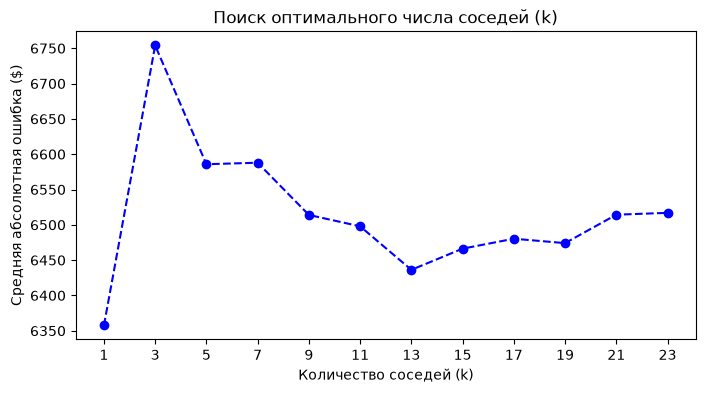

In [5]:
errors = []
k_values = range(1, 25, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(k_values, errors, marker="o", linestyle="dashed", color="blue")
plt.title("Поиск оптимального числа соседей (k)")
plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя абсолютная ошибка ($)")
plt.xticks(k_values)
plt.show()

Вывод: оптимальное k = 9 (Число соседей)

## Обучение моделей с Евклидовым расстоянием и Манхэттенским

In [6]:
best_k = 9

knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, y_train)
y_pred_euc = knn_euclidean.predict(X_test)

knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, y_train)
y_pred_man = knn_manhattan.predict(X_test)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2): MAE = ${mean_absolute_error(y_test, y_pred_euc):.2f} | R2 = {r2_score(y_test, y_pred_euc):.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = ${mean_absolute_error(y_test, y_pred_man):.2f} | R2 = {r2_score(y_test, y_pred_man):.2f}")

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = $6514.01 | R2 = 0.42
Манхэттенское расстояние (p=1): MAE = $6518.20 | R2 = 0.41


## Регрессия Надарая-Ватсона

In [7]:
gamma_values = np.logspace(-4, 0, 30)

best_gamma = 0
best_r2 = -float("inf")
best_mae = float("inf")

for g in gamma_values:
    weights = rbf_kernel(X_test, X_train, gamma=g)
    weights_normalized = weights / weights.sum(axis=1, keepdims=True)

    y_pred_nw = np.dot(weights_normalized, y_train.values)

    r2 = r2_score(y_test, y_pred_nw)
    mae = mean_absolute_error(y_test, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = g

print("=== Итоги оптимизации ядерной регрессии ===")
print(f"Оптимальный gamma: {best_gamma:.4f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: ${best_mae:.2f}")

=== Итоги оптимизации ядерной регрессии ===
Оптимальный gamma: 1.0000
Лучшее R2: 0.39
Лучшее MAE: $6646.58


## Визуализация качества модели

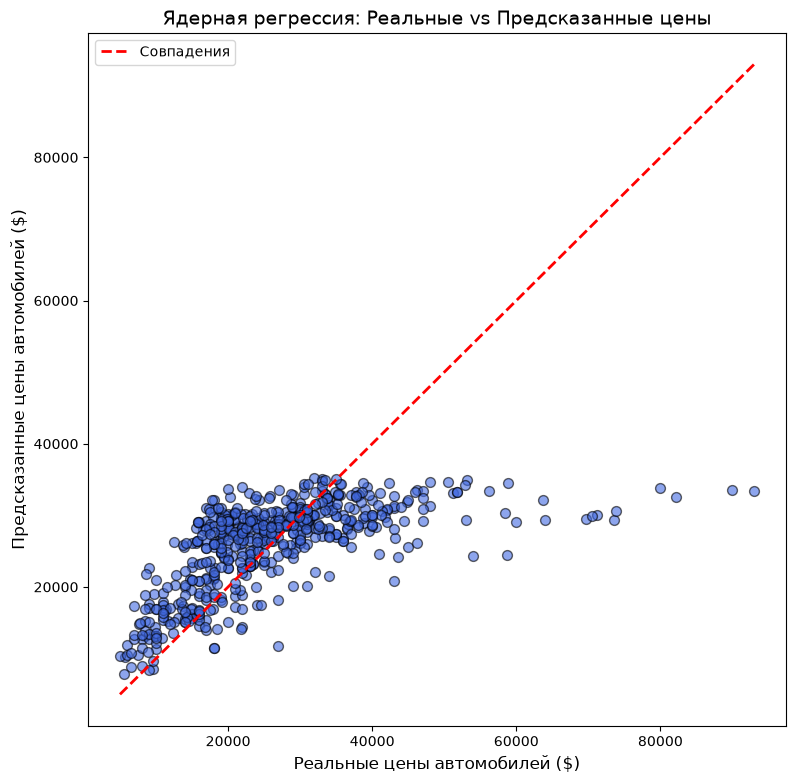

In [8]:
plt.figure(figsize=(9, 9))

plt.scatter(y_test, y_pred_nw, alpha=0.6, color="royalblue", edgecolor="k", s=50)

max_val = max(y_test.max(), y_pred_nw.max())
min_val = min(y_test.min(), y_pred_nw.min())

plt.plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Совпадения"
)

plt.title("Ядерная регрессия: Реальные vs Предсказанные цены", fontsize=14)
plt.xlabel("Реальные цены автомобилей ($)", fontsize=12)
plt.ylabel("Предсказанные цены автомобилей ($)", fontsize=12)
plt.legend()
plt.show()

Вывод: модель лучше прогнозирует машины со средней стоимостью, далее модель занижает цену